In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import os
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



# Check if matching level between cue and target in training changes performance 

### Get TIMIT pandas for metadata

In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
# df_paths

In [4]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [5]:
# pd.concat(meta_df, axis=0)

### Get experimental results csv

In [6]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [7]:
results_files

[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4941864_batch_results.csv')]

In [8]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)


In [9]:
# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [10]:
len(results.participant.unique())

50

In [11]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [12]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [13]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [14]:
len(catch_trial_particiapnt_performance) # catch trial performance for each participant 

50

In [15]:
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [16]:
good_participants

Index(['p12_1', 'p18_1', 'p18_2', 'p20_2', 'p21_2', 'p22_1', 'p25_4', 'p26_4',
       'p27_4', 'p29_4', 'p31_4', 'p37_4', 'p3_1', 'p41_4', 'p47_4', 'p48_4',
       'p4_1', 'p4_3', 'p5_0', 'p5_1', 'p5_2', 'p6_2', 'p8_0', 'p9_0'],
      dtype='object', name='participant')

In [17]:
good_results = results[results.participant.isin(good_participants)]

## Get model results all subsets

In [34]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/')
timit_results = list(parent_path.rglob("TIMIT_attn_task*all_targets_*/*/*.csv"))

# TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
# timit_results = list(parent_path.rglob("*.csv"))

wanted_models = ['MultiDistractorAttnCNN',
#                  'MultiDistractorAttnCNN_-20_to_20dB',
                 'speech_and_noise_v4',
                 'speech_and_noise_batch_norm',
                 ]
timit_results = [path.as_posix() for path in timit_results 
                 if any(model in path.as_posix() for model in wanted_models)
                 and ('clean' not in path.as_posix())]
timit_results

['/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_1/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_1/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_v4/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_3/

In [35]:
import datetime

t = os.path.getmtime(timit_results[1])
datetime.datetime.fromtimestamp(t)



datetime.datetime(2022, 12, 1, 17, 47, 3, 761131)

In [36]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [37]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [99]:
model_results = []

for path in timit_results:
#     if "-20_to_20dB" in path:
#         continue 
    if ('TIMIT_attn_task_all_targets_MultiDistractorAttnCNN' in path) and ('version_3' in path):
        continue
    if ("batch_norm" in path) and ('version_0' in path):
        continue 
    df = pd.read_csv(path)
    print(path)
    df['model'] = re.search('_targets_(.+?)/', path).group(1)
    df = df.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in df.index})
    df['pred_word_ix'] = df['pred_word_ix'].astype('int') 
    df['guessed_word'] = df['pred_word_ix'].map(class_map)

    ### Get metadata from timit df 
    df['true_word'] = model_meta_df.loc[df.orig_df_ix, ['word']].values
    df['distractor_words'] = model_meta_df.loc[df.orig_df_ix, ['distractor_words']].values
    df['distractor_sex'] = model_meta_df.loc[df.orig_df_ix, ['distractor_sex']].values
    df['snr'] = model_meta_df.loc[df.orig_df_ix, ['snrs']].values.astype('str')
    df['distractor_condition'] = model_meta_df.loc[df.orig_df_ix, ['distractor_conditions']].values.astype('str')
    df['target_sex'] = model_meta_df.loc[df.orig_df_ix, ['speaker_sex']].values
    df['confusions'] = df[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

    
    model_results.append(df)
model_results = pd.concat(model_results, axis=0, ignore_index=True)

/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_1/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_1/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_v4/version_0/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv


In [100]:
model_results.shape

(165968, 12)

In [101]:
model_results.head()

,accuracy,pred_word_ix,orig_df_ix,model,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex,confusions
0,1.0,552,0,MultiDistractorAttnCNN_-20_to_20dB,programs,programs,[working],m,-6,1,f,0
1,0.0,73,1,MultiDistractorAttnCNN_-20_to_20dB,battle,novel,[medical],m,-6,1,f,0
2,1.0,646,2,MultiDistractorAttnCNN_-20_to_20dB,should,should,[larger],m,-6,1,f,0
3,1.0,659,3,MultiDistractorAttnCNN_-20_to_20dB,social,social,[caused],m,-6,1,f,0
4,0.0,90,4,MultiDistractorAttnCNN_-20_to_20dB,black,light,[young],m,-6,1,f,0


In [102]:
model_results = model_results.replace('ssn', 'noise', regex=True)

In [103]:
model_results.distractor_condition.unique()

array(['1', '2', '4', 'noise'], dtype=object)

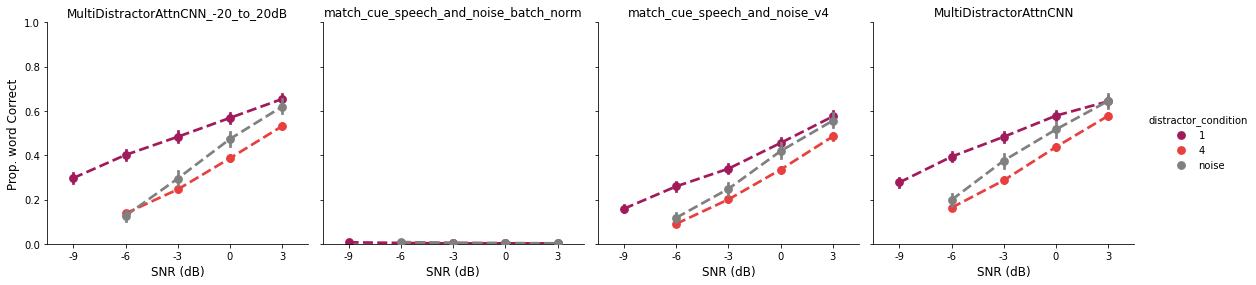

In [104]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 12

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='model',
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name}", size=fontsize)

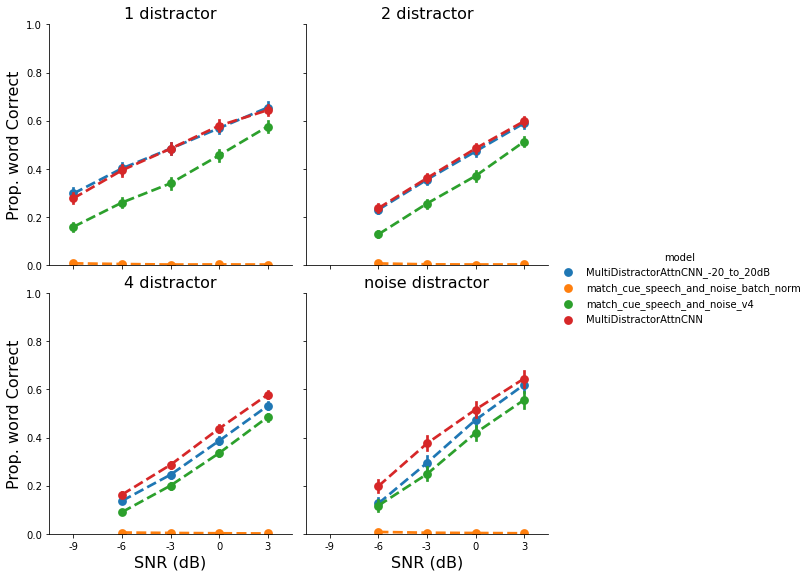

In [105]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='distractor_condition', col_wrap=2,
            hue ='model', linestyles='--',
            #hue_order=hue_order, palette=distractor_palette,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name} distractor", size=fontsize)

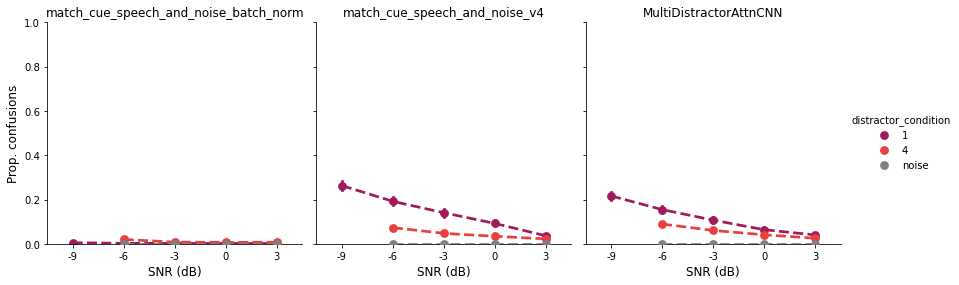

In [97]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 12

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'confusions', order=snr_order,
            col='model',
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. confusions", size=fontsize)
g.set_titles("{col_name}", size=fontsize)


In [45]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_15566/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [57]:
model_results.model.unique()

array(['match_cue_speech_and_noise_batch_norm',
       'match_cue_speech_and_noise_v4', 'MultiDistractorAttnCNN'],
      dtype=object)

In [107]:
# all_results = pd.concat([good_results, model_results[model_results.model == 'match_cue_speech_and_noise_v4']])
all_results = pd.concat([good_results, model_results])

In [126]:
all_results.model.unique()

array(['human', 'MultiDistractorAttnCNN_-20_to_20dB',
       'match_cue_speech_and_noise_batch_norm',
       'match_cue_speech_and_noise_v4', 'MultiDistractorAttnCNN'],
      dtype=object)

<a id='Attentive_listening_task'></a>
# Attentive listening task plots

In [109]:
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)

In [111]:
all_results.loc[all_results['subject'] == 'human', 'model'] = 'human'

In [112]:
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




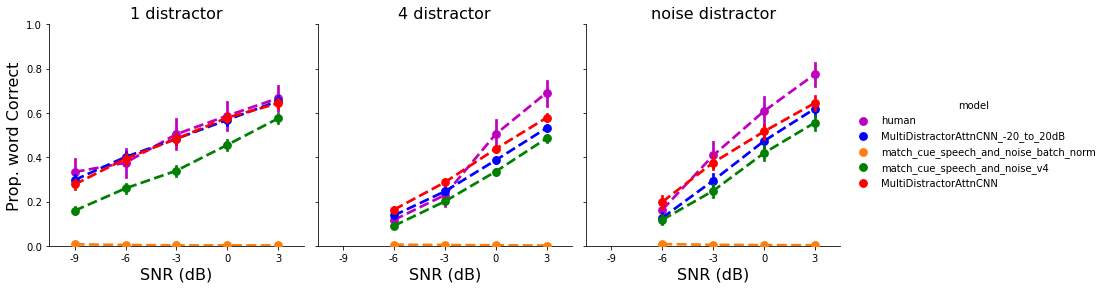

In [128]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
# hue_order = ['1', '4', 'noise']
# model_order = 'h'
model_hue = {'human':'m',
             'MultiDistractorAttnCNN_-20_to_20dB':'b',
             'match_cue_speech_and_noise_batch_norm':'tab:orange',
             'match_cue_speech_and_noise_v4':'g',
             'MultiDistractorAttnCNN':'r'}
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=all_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='distractor_condition', col_order = hue_order,
            hue ='model', linestyles='--',
            palette=model_hue,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name} distractor", size=fontsize)

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,


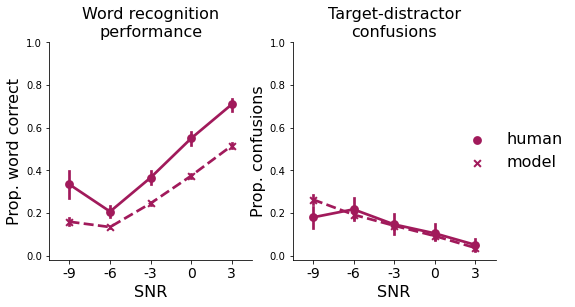

In [106]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

n_participants = len(turk_summary_df.participant.unique())
to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=all_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[1])

axs[0].set_title(f"Word recognition\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', # labels=[f"human (N={n_participants})", "model"],
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
# plt.tight_layout()
# plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.svg')

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,


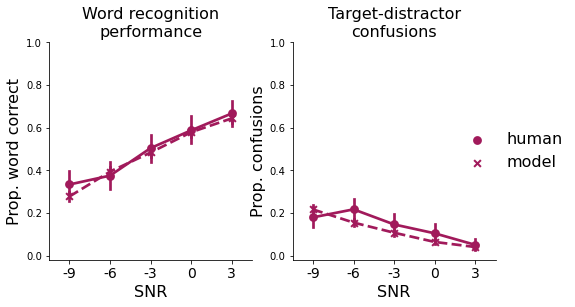

In [63]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

n_participants = len(turk_summary_df.participant.unique())
to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=to_plot, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[1])

axs[0].set_title(f"Word recognition\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', # labels=[f"human (N={n_participants})", "model"],
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
# plt.tight_layout()
# plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.svg')

<a id='sex_similarity'></a>

# Target-distractor sex similarity 



In [75]:
good_results.distractor_sex.unique()

array(['ssn', 'mfff', 'f', 'm', 'mm', 'mf', nan, 'mmff', 'mmmf', 'ffff',
       'ff', 'mmmm'], dtype=object)

In [76]:
## map male/female to same/different 


def remap_sex_strs(target_sex, distractors):
    if isinstance(distractors,float):
        return distractors
    if distractors == 'noise':
        return distractors 
    same_diff = ''.join(['s' if char == target_sex else 'd' for char in distractors])
    return same_diff

all_results['distractor_type'] = all_results[['target_sex',
                                              'distractor_sex']].apply(lambda x: remap_sex_strs(x.target_sex, x.distractor_sex),
                                                    axis=1)


In [77]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['s', 'd', 'ss', 'sd', 'dd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['ssdd'] = distractor_palette['sd']

# skip 2 distractor condition
distractor_palette = {k:v for k,v in distractor_palette.items() if len(k) !=2}
distractor_hue_order = ['s', 'd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']


[['d', 's'], ['dd', 'sd', 'ss'], ['dddd', 'sddd', 'ssdd', 'sssd', 'ssss']]


In [78]:
## Get stats for sex similarity plots:

turk_results = all_results[all_results['subject'] == 'human']

turk_accuracy_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_accuracy_df.rename(columns={'mean':'accuracy'}, inplace=True)
turk_confusion_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())
turk_confusion_df.rename(columns={'mean':'confusions'}, inplace=True)




# turk_summary_df = (turk_results.groupby(["snr", 'participant',
#                                          "distractor_condition", "distractor_sex", 'target_sex'])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

turk_accuracy_df.head()

,snr,participant,distractor_condition,distractor_type,accuracy
0,-3,p12_1,1,d,1.0
1,-3,p12_1,1,s,0.6
2,-3,p12_1,2,dd,0.0
3,-3,p12_1,2,ds,0.0
4,-3,p12_1,2,sd,1.0


In [79]:
sex_acc = pd.merge(turk_accuracy_df, all_results[all_results.subject=='model'], 
        on=['snr', 'participant', 'distractor_condition', 'distractor_type',
       'accuracy'],

        how='outer')

In [80]:
sex_acc['subject'][~sex_acc.participant.isna()] = 'human'

/tmp/ipykernel_15566/3139629851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sex_acc['subject'][~sex_acc.participant.isna()] = 'human'


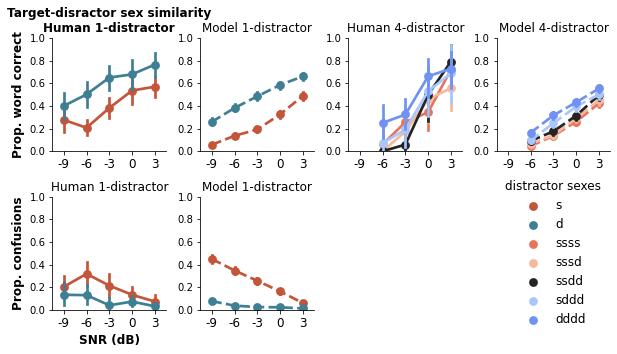

In [81]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 12


n_participants = len(turk_summary_df.participant.unique())


fig, axs = plt.subplots(2,4, figsize=(10,5), sharey=False)
axs = axs.ravel()

# 1 distractor 
g = sns.pointplot( data=sex_acc[(sex_acc.subject=='human') & (sex_acc.distractor_condition=='1')],
              x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=distractor_hue_order, palette=distractor_palette, 
            ax=axs[0])

g1 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1')], 
                   x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=distractor_hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[1])

# 4 distractor 

g2 = sns.pointplot( data=sex_acc[(sex_acc.subject=='human') & (sex_acc.distractor_condition=='4')],
              x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=distractor_hue_order, palette=distractor_palette, 
            ax=axs[2])

g3 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='4')], 
                   x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=distractor_hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[3])

# 1 distractor confusions 

g4 = sns.pointplot( data=turk_confusion_df[turk_confusion_df['distractor_condition']=='1'],
              x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=distractor_hue_order, palette=distractor_palette, 
            ax=axs[4])

g5 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1')], 
                   x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=distractor_hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[5])



axs[0].set_title(f"Target-disractor sex similarity\nHuman 1-distractor",
                 fontsize=fontsize,weight='bold')

axs[1].set_title("Model 1-distractor", fontsize=fontsize)

axs[2].set_title("Human 4-distractor", fontsize=fontsize)
axs[3].set_title("Model 4-distractor", fontsize=fontsize)

axs[4].set_title("Human 1-distractor", fontsize=fontsize)
axs[5].set_title("Model 1-distractor", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize, weight='bold')
axs[1].set_ylabel("", fontsize=fontsize)

axs[2].set_ylabel("", fontsize=fontsize)
axs[3].set_ylabel("", fontsize=fontsize)

axs[4].set_ylabel("Prop. confusions", fontsize=fontsize, weight='bold')
axs[5].set_ylabel("", fontsize=fontsize)

np.vectorize(lambda x: x.set_xlabel(''))(axs[:4])
axs[4].set_xlabel("SNR (dB)", fontsize=fontsize,weight='bold')
axs[5].set_xlabel("", fontsize=fontsize)




g.set_xticklabels(snr_order, size=fontsize)
g1.set_xticklabels(snr_order, size=fontsize)
g2.set_xticklabels(snr_order, size=fontsize)
g3.set_xticklabels(snr_order, size=fontsize)
g4.set_xticklabels(snr_order, size=fontsize)
g5.set_xticklabels(snr_order, size=fontsize)


sns.despine()


# axs[0].set_ylim((-0.02,1))
# axs[1].set_ylim((-0.02,1))


# axs[0].get_legend().remove()

axs[0].get_legend().remove()
axs[1].get_legend().remove()
axs[2].get_legend().remove()
axs[3].get_legend().remove()
axs[4].get_legend().remove()
axs[5].get_legend().remove()

np.vectorize(lambda x: x.set_ylim(0,1))(axs)


handles, labels = axs[0].get_legend_handles_labels()
axs[6].set_axis_off()

axs[7].set_axis_off()
legend = axs[7].legend(handles, labels, loc='center', title='distractor sexes',
                       frameon=False, fontsize=fontsize)
legend.get_title().set_fontsize('12')

plt.subplots_adjust(wspace=0.3,
                    hspace=0.4)

# sns.move_legend(g4, title='distractor\ncondition', 
#                 loc="center right",  bbox_to_anchor=(-1.25, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.ylim(0,1)
# fig.subplots_adjust(top=0.7) # adjust the Figure in rp
# fig.suptitle('Attentive listening task', size=fontsize)
# plt.tight_layout()
# plt.savefig(plot_out_dir / 'distractor_sex_plots.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'distractor_sex_plots.svg', bbox_inches='tight', format="svg")

<a id='harmonicity'></a>

# Harmonic v inharmonic 

### Get results from jitter_fn rendered harmonic speech 

In [122]:

parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
harmonic_file = parent_path.rglob("*.csv")
harmonic_results = pd.read_csv(next(harmonic_file))

# For clean, use version_1 for Harmonic speech generated with shift f0 function
# For clean, use version_2 for Harmonic speech generated with STRAIGHT resynth via - StraightDummySynth.m

clean_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
clean_harmonic_file = clean_path.rglob("*.csv")
clean_harmonic_results = pd.read_csv(next(clean_harmonic_file))

harmonic_results = harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
harmonic_results['pred_word_ix'] = harmonic_results['pred_word_ix'].astype('int') 

clean_harmonic_results = clean_harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in clean_harmonic_results.index})
clean_harmonic_results['pred_word_ix'] = clean_harmonic_results['pred_word_ix'].astype('int') 


### Get metadata for harmonic stimuli

In [204]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/harmonic_timit/')

harmonic_meta_data = pd.read_pickle(out_path / 'all_targets_harmonic_single_distractor_0dB_SNR_jitter_fn_render.pdpkl')

In [205]:
harmonic_results['guessed_word'] = harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
harmonic_results['true_word'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['word']].values
harmonic_results['distractor_words'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_words']].values
harmonic_results['distractor_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_sex']].values
harmonic_results['snr'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
harmonic_results['distractor_condition'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
harmonic_results['target_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['speaker_sex']].values

harmonic_results['distractor_condition'] = 'Harmonic'

clean_harmonic_results['guessed_word'] = clean_harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_harmonic_results['true_word'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['word']].values
clean_harmonic_results['target_sex'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['speaker_sex']].values

clean_harmonic_results['distractor_condition'] = 'Harmonic Clean'


### Get Inharmonic Results

In [206]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
inharm_file = parent_path.rglob("*.csv")
inharm_results = pd.read_csv(next(inharm_file))

clean_inharm_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/')
clean_inharm_path = clean_inharm_path / 'TIMIT_inharmonic_speech_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/'

clean_inharm_path = clean_inharm_path.rglob('*.csv')
clean_inharm_results = pd.read_csv(next(clean_inharm_path))

clean_inharm_results = clean_inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
clean_inharm_results['pred_word_ix'] = clean_inharm_results['pred_word_ix'].astype('int') 

inharm_results = inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
inharm_results['pred_word_ix'] = inharm_results['pred_word_ix'].astype('int') 

In [207]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

In [208]:
clean_inharm_results['guessed_word'] = clean_inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_inharm_results['true_word'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['word']].values
clean_inharm_results['target_sex'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['speaker_sex']].values



In [209]:
clean_inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter) Clean'

In [210]:
inharm_results['guessed_word'] = inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
inharm_results['true_word'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['word']].values
inharm_results['distractor_words'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_words']].values
inharm_results['distractor_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_sex']].values
inharm_results['snr'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['snrs']].values.astype('str')
inharm_results['distractor_condition'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
inharm_results['target_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['speaker_sex']].values



In [211]:
inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter)'

In [212]:
## combine_dfs 

harmonicity_results = pd.concat([harmonic_results,
                         clean_harmonic_results,
                         inharm_results,
                         clean_inharm_results], ignore_index=True)

get_confusion = lambda row: int(row.guessed_word in row.distractor_words) if not isinstance(row.distractor_words, float) else row.distractor_words

harmonicity_results['confusion'] = harmonicity_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)


In [213]:
spch_rslts = pd.melt(harmonicity_results, id_vars=['distractor_condition'],

        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

spch_rslts['attended_stream'][spch_rslts['distractor_condition'].str.contains('Clean')] = "Single sentence"
spch_rslts['distractor_condition'] = spch_rslts['distractor_condition'].apply(lambda x: x.replace(' Clean', ''))


/tmp/ipykernel_3241/2643542157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_3241/2643542157.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"
/tmp/ipykernel_3241/2643542157.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_

In [214]:
spch_rslts

,distractor_condition,attended_stream,hits
0,Harmonic,Cued stream,1.0
1,Harmonic,Cued stream,0.0
2,Harmonic,Cued stream,0.0
3,Harmonic,Cued stream,0.0
4,Harmonic,Cued stream,1.0
...,...,...,...
7211,Inharmonic \n (0.3 jitter),Single sentence,NaN
7212,Inharmonic \n (0.3 jitter),Single sentence,NaN
7213,Inharmonic \n (0.3 jitter),Single sentence,NaN
7214,Inharmonic \n (0.3 jitter),Single sentence,NaN


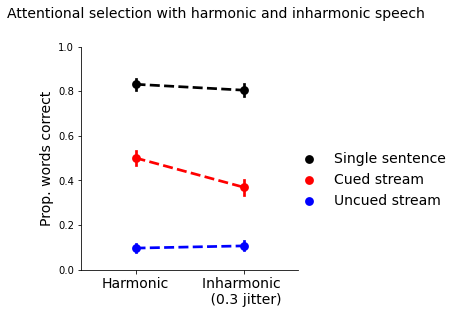

In [454]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    linestyles='--',
    height=4, ratio=.75,
)


g.set_axis_labels("", "Prop. words correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Attentional selection with harmonic and inharmonic speech', y = 1.1,size=fontsize)
# g.fig.tight_layout()
# plt.savefig(plot_out_dir / 'harmonicity_plot.pdf',  bbox_inches='tight')
# plt.savefig(plot_out_dir / 'harmonicity_plot.svg',  format="svg", bbox_inches='tight')

<a id='corrs'></a>

# Target-mixture correlations by Layer

In [51]:
corr_paths = list(Path('../').glob('*corrs*.pkl'))
skip = 'attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs'
corr_paths = [path for path in corr_paths if ('noise' not in path.stem) and (path.stem != skip)]

In [52]:
model_dfs = []

for path in corr_paths:
    with open(path, 'rb') as f:
        acts = pickle.load(f)
    for layer in acts['fg_corr_results'].keys():
        df = pd.DataFrame.from_dict({'fg_corrs':acts['fg_corr_results'][layer],
                                 'bg_corrs':acts['bg_corr_results'][layer],
                                 'layer': [layer] * len(acts['fg_corr_results'][layer])})
    #                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
        df['model'] = path.stem
        model_dfs.append(df)

model_df = pd.concat(model_dfs)


In [53]:
model_df['with_noise'] = model_df.model.str.contains('audioset')

In [54]:

results = pd.melt(model_df, id_vars =['layer','with_noise', 'model'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [55]:
results = (results.groupby(["layer", 'Stream', 'with_noise', 'model'])["Pearson's r"]
                     .agg(["mean"])
                     .reset_index())
results = results.rename(columns={'mean':"Pearson's r"})

In [56]:

results['Stream'].replace('fg_corrs','corr(target, mixture)',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture)',inplace=True)


In [57]:
layer_order = sorted(results.layer.unique())

/tmp/ipykernel_15733/2781521136.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)


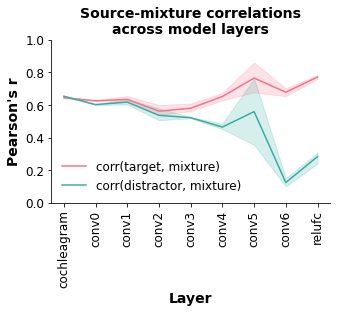

In [58]:

fontsize=14

fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(5,3)

g = sns.lineplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', 
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],)
#               order = layer_order,
#               dodge=0.1,
#               ax=ax,
#               height=1, #ratio=2,
#               error='sem')

sns.despine()
g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)

g.set_yticks(np.linspace(0,1,6))
g.set_yticklabels(np.linspace(0,1,6).round(1), fontsize=fontsize-2)

g.set_ylabel("Pearson's r", fontsize=fontsize, weight='bold')
g.set_xlabel("Layer", fontsize=fontsize, weight='bold')
g.set_title("Source-mixture correlations\nacross model layers", size=fontsize, weight='bold')
sns.move_legend(g, title='',
                loc="lower left", 
                frameon=False, fontsize=fontsize-2 )


# plt.savefig(plot_out_dir / 'layer_corrs.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'layer_corrs.svg', bbox_inches='tight' ,format="svg")

# plt.tight_layout()

In [49]:
plot_out_dir

PosixPath('/om2/user/imgriff/projects/cocktail_party/COSYNE_2023/plots')

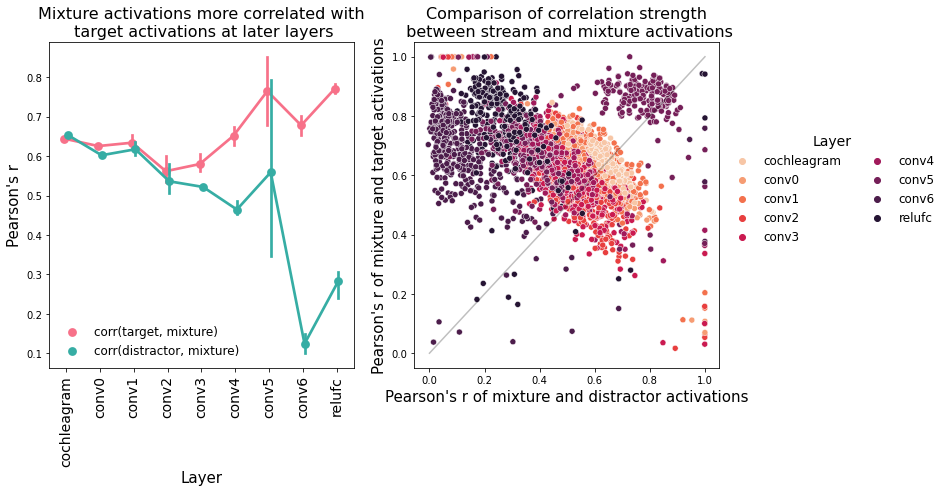

In [164]:
fig, axs = plt.subplots(1,2, figsize=(12,6))


x = y = np.linspace(0,1,100)

sns.pointplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[0],
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
              order = layer_order,
              dodge=0.1,
              error='sem')


axs[1].plot(x,y,'k-', alpha=0.25)
sns.scatterplot(data=model_df, x='bg_corrs', y='fg_corrs',
                hue='layer',hue_order=layer_order, palette='rocket_r', ax=axs[1])


axs[0].set_title("Mixture activations more correlated with\n target activations at later layers", fontsize=16)
axs[0].set_xticklabels(layer_order, rotation=90, fontsize=14);
axs[0].set_ylabel("Pearson's r", fontsize=15)
axs[0].set_xlabel("Layer", fontsize=15)
axs[0].legend(title='', loc='lower left', frameon=False,
              fontsize=12, title_fontsize=14)


axs[1].set_title("Comparison of correlation strength\n between stream and mixture activations", fontsize=16)
axs[1].set_xlabel("Pearson's r of mixture and distractor activations", fontsize=15)
axs[1].set_ylabel("Pearson's r of mixture and target activations", fontsize=15)
axs[1].legend(title='Layer', ncol=2, frameon=False,
              bbox_to_anchor=(1, 0.75), fontsize=12, title_fontsize=14)




# plt.tight_layout()

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:3775: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try pointplot
  warnings.warn(msg, UserWarning)


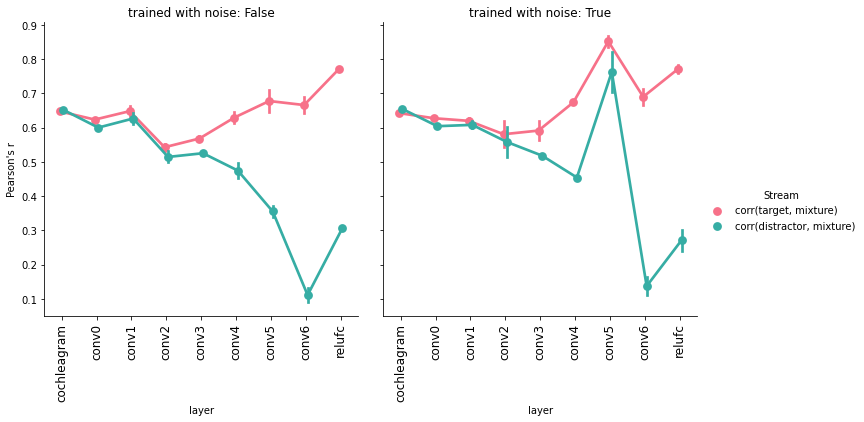

In [174]:
g = sns.catplot(kind='point', data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[0],
              col='with_noise',
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
              order = layer_order,
              dodge=0.1,
              error='sem')

g.set_xticklabels(rotation=90, fontsize=fontsize)
# g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("trained with noise: {col_name}", size=fontsize)